# Présentation générale du sujet

Ce projet vise à prédire la consommation d’énergie des appareils électroménagers dans une maison à faible consommation d’énergie en utilisant des techniques avancées d’apprentissage automatique avec Apache Spark MLlib.

La problématique centrale réside dans l’identification des facteurs qui influent le plus sur la consommation d’énergie des appareils électroménagers, ainsi que dans la construction de modèles prédictifs robustes et précis.

Le jeu de données utilisé dans ce projet provient du site UCI Machine Learning Repository, accessible à l’adresse suivante : http://archive.ics.uci.edu/dataset/374/appliances+energy+prediction. Ce jeu de données contient des données expérimentales utilisées pour créer des modèles de régression de la consommation énergétique des appareils dans un batiment à basse consommation énergétique.

## Importation des Librairies nécessaires

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
#from pyspark.sql.functions import col
from pyspark.sql.functions import col, year, month, dayofyear, hour, minute, second,when
from pyspark.sql.types import * # les types de données de Spark
import pyspark.sql.functions as sql_f # import des fonctions SQL 
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.functions import month, sum, udf
from pyspark.sql.types import StringType
import seaborn as sns
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import VectorAssembler


### Creation d'une session Spark

In [2]:
spark = SparkSession.builder \
    .appName("MLIB Project") \
    .getOrCreate()


24/02/26 20:50:48 WARN Utils: Your hostname, V304V-JCP002.campus.unicaen.fr resolves to a loopback address: 127.0.1.1; using 10.16.17.84 instead (on interface ens160)
24/02/26 20:50:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


24/02/26 20:50:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Chargement des Données

### Definition de notre schema de Données

In [3]:
schema_membres = StructType([\
                
                            StructField('date', DateType(), True),\
                            StructField('Appliances', FloatType(), True),\
                            StructField('lights', FloatType(), True),\
                            StructField('T1', FloatType(), True),\
                            StructField('RH_1',FloatType(), True),\
                            StructField('T2', FloatType(), True),\
                            StructField('RH_2', FloatType(), True),\
                            StructField('T3', FloatType(), True),\
                            StructField('RH_3', FloatType(), True),\
                            StructField('T4', FloatType(), True),\
                            StructField('RH_4', FloatType(), True),\
                            StructField('T5', FloatType(), True),\
                            StructField('RH_5', FloatType(), True),\
                            StructField('T6', FloatType(), True),\
                            StructField('RH_6', FloatType(), True),\
                            StructField('T7', FloatType(), True),\
                            StructField('RH_7', FloatType(), True),\
                            StructField('T8', FloatType(), True),\
                            StructField('RH_8', FloatType(), True),\
                            StructField('T9', FloatType(), True),\
                            StructField('RH_9', FloatType(), True),\
                            StructField('T_out', FloatType(), True),\
                            StructField('Press_mm_hg', FloatType(), True),\
                            StructField('RH_out', FloatType(), True),\
                            StructField('Windspeed', FloatType(), True),\
                            StructField('Visibility', FloatType(), True),\
                            StructField('Tdewpoint', FloatType(), True),\
                            StructField('rv1', FloatType(), True),\
                            StructField('rv2', FloatType(), True),\
                             
                        
                            ])


In [4]:
df = spark.read.csv("energydata_complete.csv", schema=schema_membres, header=True)


In [5]:

# Sélection des colonnes à conserver
columns_to_keep = [field.name for field in schema_membres.fields if field.name != 'date']

# Conversion des colonnes String en numériques et ajout de colonnes supplémentaires
df_new = df.select(
    *[col(field.name).cast("float").alias(field.name) for field in schema_membres.fields if field.name != 'date'],
    dayofyear("date").alias("day_of_year"),
    hour("date").alias("hour_of_day"),
    month("date").alias("month_of_year")
)

# Affichage du nouveau DataFrame
df_new.show(2)


24/02/26 20:51:03 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
+----------+------+-----+---------+----+-------+-----+-----+----+---------+---------+----+---------+--------+----+---------+----+---------+---------+-----+--------+-----------+------+---------+----------+---------+---------+---------+-----------+-----------+-------------+
|Appliances|lights|   T1|     RH_1|  T2|   RH_2|   T3| RH_3|  T4|     RH_4|       T5|RH_5|       T6|    RH_6|  T7|     RH_7|  T8|     RH_8|       T9| RH_9|   T_out|Press_mm_hg|RH_out|Windspeed|Visibility|Tdewpoint|      rv1|      rv2|day_of_year|hour_of_day|month_of_year|
+----------+------+-----+---------+----+-------+-----+-----+----+---------+---------+----+---------+--------+----+---------+----+---------+---------+-----+--------+-----------+------+---------+----------+---------+---------+---------+-----------+-----------+-------------+
|

### Mise en Cache de nos Données

In [6]:
# Enregistrons notre DataFrame en tant que table temporaire
df.createOrReplaceTempView("df_temp")

# Mettons la table en cache
spark.catalog.cacheTable("df_temp")

# Vérifions si la table est mise en cache
if spark.catalog.isCached("df_temp"):
    # Obtenir le nombre total de lignes dans la table
    num_rows = spark.sql("SELECT COUNT(*) FROM df_temp").collect()[0][0]
    
    # Obtenir la taille moyenne d'une ligne en octets (approximativement)
    avg_row_size_bytes = df.rdd.map(lambda row: len(row)).mean()
    
    # Calculer la taille totale en octets
    total_size_bytes = num_rows * avg_row_size_bytes
    
    print("Nombre total de lignes:", num_rows)
    #print("Taille moyenne d'une ligne en octets:", avg_row_size_bytes)
    print("Taille totale des données en cache en octets:", total_size_bytes)


Nombre total de lignes: 19735
Taille totale des données en cache en octets: 572315.0



[Stage 4:===========================================================(3 + 0) / 3]



## Visualisation des Données

In [8]:
df_new.columns

['Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'rv1',
 'rv2',
 'day_of_year',
 'hour_of_day',
 'month_of_year']

###  Graphique indiquant l’énergie dépensée dans les appareils électroménagers en fonction du mois


[Stage 7:>                                                          (0 + 1) / 1]



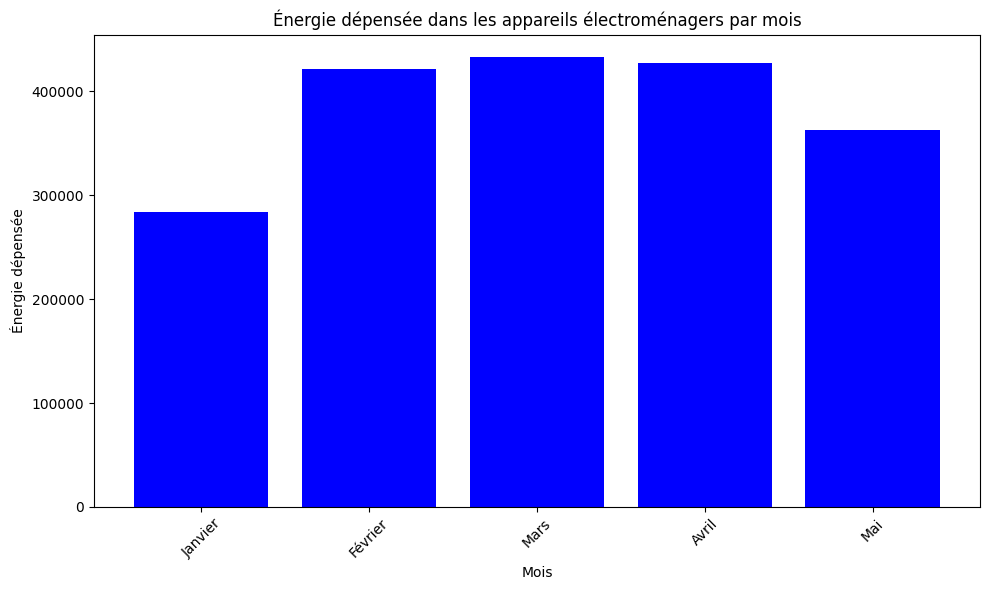

In [9]:


# Définir une fonction de conversion des mois
def map_month(month_num):
    months_dict = {
        1: "Janvier", 2: "Février", 3: "Mars", 4: "Avril", 5: "Mai", 6: "Juin",
        7: "Juillet", 8: "Août", 9: "Septembre", 10: "Octobre", 11: "Novembre", 12: "Décembre"
    }
    return months_dict.get(month_num, "Inconnu")

# Enregistrer la fonction de conversion comme une fonction UDF (User Defined Function)
map_month_udf = udf(map_month, StringType())

# Grouper par mois et calculer la somme de l'énergie dépensée
monthly_energy = df_new.groupBy('month_of_year').agg({'Appliances': 'sum'}).withColumnRenamed("sum(Appliances)", "total_energy")

# Appliquer la fonction UDF pour convertir les numéros de mois en noms de mois
monthly_energy = monthly_energy.withColumn("month_name", map_month_udf("month_of_year"))

# Convertir le DataFrame Spark en Pandas DataFrame pour le tracer avec matplotlib
monthly_energy_pd = monthly_energy.toPandas()

# Tracer le graphique
plt.figure(figsize=(10, 6))
plt.bar(monthly_energy_pd["month_name"], monthly_energy_pd["total_energy"], color='blue')
plt.xlabel('Mois')
plt.ylabel('Énergie dépensée')
plt.title('Énergie dépensée dans les appareils électroménagers par mois')
plt.xticks(rotation=45)
plt.tight_layout()

# Sauvegarder l'image
plt.savefig('energie_par_mois.png')

plt.show()


In [10]:
# Dictionnaire pour mapper le numéro du mois à son nom
months_dict = {
    1: "Janvier", 2: "Février", 3: "Mars", 4: "Avril", 5: "Mai", 6: "Juin",
    7: "Juillet", 8: "Août", 9: "Septembre", 10: "Octobre", 11: "Novembre", 12: "Décembre"
}

# Ajouter une nouvelle colonne contenant le nom des mois pour les 5 premiers mois
monthly_energy = monthly_energy.withColumn("month_name", 
                                           when(monthly_energy["month_of_year"] == 1, "Janvier")
                                           .when(monthly_energy["month_of_year"] == 2, "Février")
                                           .when(monthly_energy["month_of_year"] == 3, "Mars")
                                           .when(monthly_energy["month_of_year"] == 4, "Avril")
                                           .when(monthly_energy["month_of_year"] == 5, "Mai"))

# Affichage des résultats
monthly_energy.show()


+-------------+------------+----------+
|month_of_year|total_energy|month_name|
+-------------+------------+----------+
|            1|    283510.0|   Janvier|
|            2|    421550.0|   Février|
|            3|    432800.0|      Mars|
|            4|    427200.0|     Avril|
|            5|    362950.0|       Mai|
+-------------+------------+----------+



#### Hypothèse


En analysant les données de consommation d'énergie pour chaque mois de l'année, nous avons constaté que le mois de mars affiche systématiquement la consommation la plus élevée. En effet, selon nos calculs, le mois de mars présente une consommation totale d'énergie de 432800 watts, dépassant celle des autres mois de l'année. Ces résultats suggère qu'il pourrait y avoir des facteurs saisonniers ou des événements particuliers spécifiques au mois de mars qui contribuent à cette augmentation de la consommation d'énergie.


### Tendances temporelles quotidiennes 

Ce graphique de ligne montre la consommation d'énergie par jour.

In [ ]:
# # Sélection des colonnes pertinentes
# daily_energy = df_new.select("day_of_year", "Appliances").groupBy("day_of_year").sum('Appliances').withColumnRenamed("sum(Appliances)", "Total_Energy")

# # Affichage des résultats
# #daily_energy.show()

# # Visualisation
# # Conversion en Pandas DataFrame pour le traçage
# daily_energy_pd = daily_energy.toPandas()

# # Traçage de la tendance temporelle quotidienne
# plt.figure(figsize=(10, 6))
# plt.plot(daily_energy_pd["day_of_year"], daily_energy_pd["Total_Energy"])
# plt.xlabel("Jour de l'année")
# plt.ylabel("Consommation d'énergie totale")
# plt.title("Tendance Temporelle Quotidienne de la Consommation d'énergie")
# plt.grid(True)
# plt.savefig('tendance.png')
# plt.show()




Distribution de la consommation d'énergie 

Cet histogramme permet de visualiser la distribution de la consommation d'énergie. Cela nous donne un aperçu de la variation et de la dispersion des données.

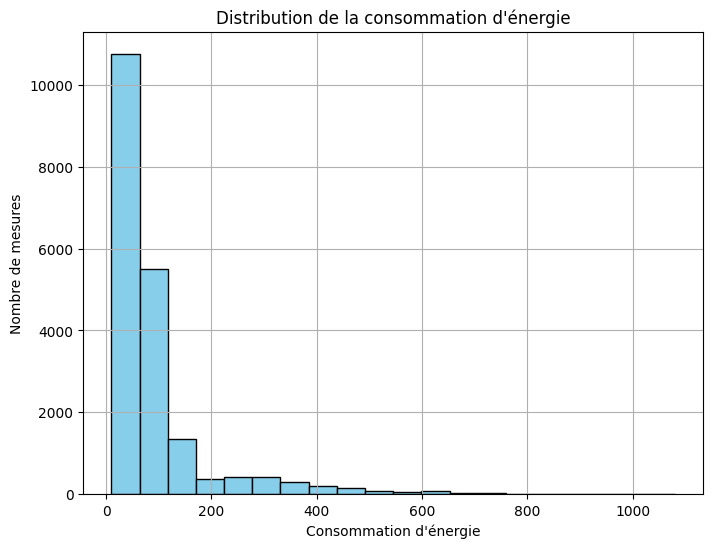

In [16]:
# Tracer un histogramme de la consommation d'énergie

df_pd=df_new.toPandas()
plt.figure(figsize=(8, 6))
plt.hist(df_pd['Appliances'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution de la consommation d\'énergie')
plt.xlabel('Consommation d\'énergie')
plt.ylabel('Nombre de mesures')
plt.grid(True)
plt.savefig('distribution_conso.png')
plt.show()


## Echantillonner les données et Normalisation des Données


La graine est fixée à 42 pour garantir des résultats cohérents. L'utilisation de la même graine garantit que les échantillons seront divisés de la même manière à chaque exécution du code, fournissant ainsi des résultats cohérents.

In [28]:
# Assembler les caractéristiques en un seul vecteur (excluant la colonne cible "Appliances")
assembler = VectorAssembler(inputCols= df_new.columns , outputCol="features")

# Assembler les vecteurs
trame_assembled = assembler.transform(df_new)

# Instancier le scaler
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)

# Calculer les statistiques du modèle et normaliser les données
scalerModel = scaler.fit(trame_assembled)
trame_scaled = scalerModel.transform(trame_assembled)

# Définition de la graine
seed = 42

# Division de l'ensemble de données normalisé en échantillons d'entraînement et de test (70% train, 30% test)
train_scaled, test_scaled = trame_scaled.randomSplit([0.7, 0.3], seed=seed)

print("Taille de l'échantillon d'entraînement (scaled) :", train_scaled.count())
print("Taille de l'échantillon de test (scaled) :", test_scaled.count())





Taille de l'échantillon d'entraînement (scaled) : 13987
Taille de l'échantillon de test (scaled) : 5748


## Réaliser un apprentissage avec Spark ML

Dans cette étude, nous avons exploré l'utilisation de Spark ML pour la modélisation et la prédiction des données. Nous avons choisi d'utiliser deux modèles différents : la régression linéaire et la forêt aléatoire, afin de comparer leurs performances dans le cadre de notre tâche de prédiction et le temps d'apprentissage.

## Cas avec validation croisée 


Avec 3 Folds

In [64]:
# Modèles de régression
lr = LinearRegression(labelCol="Appliances")
rf = RandomForestRegressor(labelCol="Appliances")

# Paramètres de grille pour la validation croisée
paramGrid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.1, 0.01]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5]) \
    .build()

paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf.maxDepth, [5, 10]) \
    .addGrid(rf.numTrees, [10, 50]) \
    .build()

# Métrique d'évaluation
evaluator = RegressionEvaluator(labelCol="Appliances", predictionCol="prediction", metricName="rmse")

# Validation croisée
cv_lr = CrossValidator(estimator=lr, estimatorParamMaps=paramGrid_lr, evaluator=evaluator, numFolds=3)
cv_rf = CrossValidator(estimator=rf, estimatorParamMaps=paramGrid_rf, evaluator=evaluator, numFolds=3)

# Entraînement et évaluation des modèles avec validation croisée
start_time = time.time()
cvModel_lr = cv_lr.fit(train_scaled)
end_time = time.time()
training_time_lr_cv = end_time - start_time

start_time = time.time()
cvModel_rf = cv_rf.fit(train_scaled)
end_time = time.time()
training_time_rf_cv = end_time - start_time 


# Prédictions sur les données de test normalisées
predictions_lr = cvModel_lr.transform(test_scaled)
predictions_rf = cvModel_rf.transform(test_scaled)

# Évaluation des modèles
rmse_lr_cv = evaluator.evaluate(predictions_lr)
rmse_rf_cv = evaluator.evaluate(predictions_rf)

print("Linear Regression - RMSE:", rmse_lr_cv)
print("Random Forest - RMSE:", rmse_rf_cv)
print("Linear Regression - Training time:", training_time_lr_cv)
print("Random Forest - Training time:", training_time_rf_cv)


24/02/26 23:49:53 WARN DAGScheduler: Broadcasting large task binary with size 1097.8 KiB
24/02/26 23:49:55 WARN DAGScheduler: Broadcasting large task binary with size 1122.8 KiB
24/02/26 23:49:55 WARN DAGScheduler: Broadcasting large task binary with size 1928.1 KiB
24/02/26 23:49:56 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
24/02/26 23:49:57 WARN DAGScheduler: Broadcasting large task binary with size 4.8 MiB



[Stage 3085:=====================================>                  (2 + 1) / 3]



24/02/26 23:50:02 WARN DAGScheduler: Broadcasting large task binary with size 1066.2 KiB
24/02/26 23:50:03 WARN DAGScheduler: Broadcasting large task binary with size 1120.3 KiB
24/02/26 23:50:04 WARN DAGScheduler: Broadcasting large task binary with size 1897.9 KiB
24/02/26 23:50:05 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
24/02/26 23:50:06 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB


24/02/26 23:50:10 WARN DAGScheduler: Broadcasting large task binary with size 1053.8 KiB
24/02/26 23:50:11 WARN DAGScheduler: Broadcasting large task binary with size 1115.1 KiB
24/02/26 23:50:12 WARN DAGScheduler: Broadcasting large task binary with size 1888.3 KiB
24/02/26 23:50:13 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
24/02/26 23:50:14 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
24/02/26 23:50:17 WARN DAGScheduler: Broadcasting large task binary with size 1096.1 KiB
24/02/26 23:50:17 WARN DAGScheduler: Broadcasting large task binary with size 1918.4 KiB
24/02/26 23:50:18 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
24/02/26 23:50:19 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB


Linear Regression - RMSE: 0.011163752245113123
Random Forest - RMSE: 16.475440073673493
Linear Regression - Training time: 3.310866355895996
Random Forest - Training time: 30.368755102157593


## Cas sans validation croisée 

In [60]:
# Définition des modèles de régression linéaire et de forêt aléatoire
lr = LinearRegression(featuresCol='features', labelCol='Appliances', maxIter=10, regParam=0.3, elasticNetParam=0.8)
rf = RandomForestRegressor(featuresCol='features', labelCol='Appliances')

# Entraînement et évaluation des modèles sans validation croisée
start_time = time.time()
model_lr = lr.fit(train_scaled)
end_time = time.time()
training_time_lr = end_time - start_time

start_time = time.time()
model_rf = rf.fit(train_scaled)
end_time = time.time()
training_time_rf = end_time - start_time

#Importance des variables
feature_importance_rf = model_rf.featureImportances

# Prédictions
predictions_lr = model_lr.transform(test_scaled)
predictions_rf = model_rf.transform(test_scaled)

# Évaluation des modèles
evaluator = RegressionEvaluator(labelCol="Appliances", predictionCol="prediction", metricName="rmse")

rmse_lr = evaluator.evaluate(predictions_lr)
rmse_rf = evaluator.evaluate(predictions_rf)

print("Linear Regression - RMSE:", rmse_lr)
print("Random Forest - RMSE:", rmse_rf)
print("Linear Regression - Training time:", training_time_lr)
print("Random Forest - Training time:", training_time_rf)


Linear Regression - RMSE: 0.9209017646190374
Random Forest - RMSE: 32.5774746108658
Linear Regression - Training time: 0.2755885124206543
Random Forest - Training time: 0.8043386936187744


## Cas du Retrait des colonnes aléatoires sans Validation Croisée

In [69]:
# Retrait des colonnes aléatoires
df_no_random = trame_scaled.drop("rv1", "rv2")

# Définition des modèles de régression linéaire et de forêt aléatoire
lr_no_random = LinearRegression(featuresCol='scaledFeatures', labelCol='Appliances', maxIter=10, regParam=0.3, elasticNetParam=0.8)
rf_no_random = RandomForestRegressor(featuresCol='scaledFeatures', labelCol='Appliances', numTrees=10)

# Entraînement et évaluation du modèle de régression linéaire sans les colonnes aléatoires
start_time = time.time()
model_lr_no_random = lr_no_random.fit(train_scaled)
end_time = time.time()
training_time_lr_no_random = end_time - start_time

# Prédictions
predictions_lr_no_random = model_lr_no_random.transform(test_scaled)

# Évaluation du modèle de régression linéaire
evaluator = RegressionEvaluator(labelCol="Appliances", predictionCol="prediction", metricName="rmse")
rmse_lr_no_random = evaluator.evaluate(predictions_lr_no_random)

print("Linear Regression - RMSE:", rmse_lr_no_random)
print("Linear Regression - Training time:", training_time_lr_no_random)

# Entraînement et évaluation du modèle de forêt aléatoire sans les colonnes aléatoires
start_time = time.time()
model_rf_no_random = rf_no_random.fit(train_scaled)
end_time = time.time()
training_time_rf_no_random = end_time - start_time

# Obtention de l'importance des attributs pour le modèle de forêt aléatoire
feature_importance_rf = model_rf_no_random.featureImportances

# Prédictions
predictions_rf_no_random = model_rf_no_random.transform(test_scaled)

# Évaluation du modèle de forêt aléatoire
rmse_rf_no_random = evaluator.evaluate(predictions_rf_no_random)

print("Random Forest - RMSE:", rmse_rf_no_random)
print("Random Forest - Training time:", training_time_rf_no_random)

# Création d'une liste pour stocker l'importance des attributs
feature_importance_values_rf = feature_importance_rf.toArray().tolist()

Linear Regression - RMSE: 0.9209017646305346
Linear Regression - Training time: 0.44881391525268555
Random Forest - RMSE: 38.565589944467426
Random Forest - Training time: 0.7934019565582275


## Cas du Retrait des colonnes aléatoires avec Validation Croisée

In [70]:

# Retrait des colonnes aléatoires
df_no_random = trame_scaled.drop("rv1", "rv2")

# Définition des modèles de régression linéaire et de forêt aléatoire
lr_no_random = LinearRegression(featuresCol='scaledFeatures', labelCol='Appliances', maxIter=10, regParam=0.3, elasticNetParam=0.8)
rf_no_random = RandomForestRegressor(featuresCol='scaledFeatures', labelCol='Appliances', numTrees=10)

# Paramètres de grille pour la validation croisée
paramGrid_lr_no_random = ParamGridBuilder() \
    .addGrid(lr_no_random.regParam, [0.1, 0.01]) \
    .addGrid(lr_no_random.elasticNetParam, [0.0, 0.5]) \
    .build()

paramGrid_rf_no_random = ParamGridBuilder() \
    .addGrid(rf_no_random.maxDepth, [5, 10]) \
    .addGrid(rf_no_random.numTrees, [10, 50]) \
    .build()

# Métrique d'évaluation
evaluator = RegressionEvaluator(labelCol="Appliances", predictionCol="prediction", metricName="rmse")

# Validation croisée
cv_lr_no_random = CrossValidator(estimator=lr_no_random, estimatorParamMaps=paramGrid_lr_no_random, evaluator=evaluator, numFolds=3)
cv_rf_no_random = CrossValidator(estimator=rf_no_random, estimatorParamMaps=paramGrid_rf_no_random, evaluator=evaluator, numFolds=3)

# Entraînement et évaluation des modèles avec validation croisée
start_time = time.time()
cvModel_lr_no_random = cv_lr_no_random.fit(train_scaled)
end_time = time.time()
training_time_lr_no_random = end_time - start_time

start_time = time.time()
cvModel_rf_no_random = cv_rf_no_random.fit(train_scaled)
end_time = time.time()
training_time_rf_no_random = end_time - start_time

# Prédictions
predictions_lr_no_random = cvModel_lr_no_random.transform(test_scaled)
predictions_rf_no_random = cvModel_rf_no_random.transform(test_scaled)

# Évaluation des modèles
rmse_lr_no_random = evaluator.evaluate(predictions_lr_no_random)
rmse_rf_no_random = evaluator.evaluate(predictions_rf_no_random)

print("Linear Regression (CV) - RMSE:", rmse_lr_no_random)
print("Random Forest (CV) - RMSE:", rmse_rf_no_random)
print("Linear Regression (CV) - Training time:", training_time_lr_no_random)
print("Random Forest (CV) - Training time:", training_time_rf_no_random)


24/02/27 02:27:03 WARN DAGScheduler: Broadcasting large task binary with size 1097.8 KiB
24/02/27 02:27:05 WARN DAGScheduler: Broadcasting large task binary with size 1122.8 KiB
24/02/27 02:27:05 WARN DAGScheduler: Broadcasting large task binary with size 1928.1 KiB
24/02/27 02:27:06 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
24/02/27 02:27:07 WARN DAGScheduler: Broadcasting large task binary with size 4.8 MiB
24/02/27 02:27:12 WARN DAGScheduler: Broadcasting large task binary with size 1066.2 KiB
24/02/27 02:27:13 WARN DAGScheduler: Broadcasting large task binary with size 1120.7 KiB
24/02/27 02:27:14 WARN DAGScheduler: Broadcasting large task binary with size 1901.2 KiB
24/02/27 02:27:15 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
24/02/27 02:27:16 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
24/02/27 02:27:20 WARN DAGScheduler: Broadcasting large task binary with size 1053.8 KiB
24/02/27 02:27:22 WARN DAGSchedul

Linear Regression (CV) - RMSE: 0.011163752244828433
Random Forest (CV) - RMSE: 16.598101138708756
Linear Regression (CV) - Training time: 3.9593255519866943
Random Forest (CV) - Training time: 31.43924355506897


## Comparaison graphique des modèles

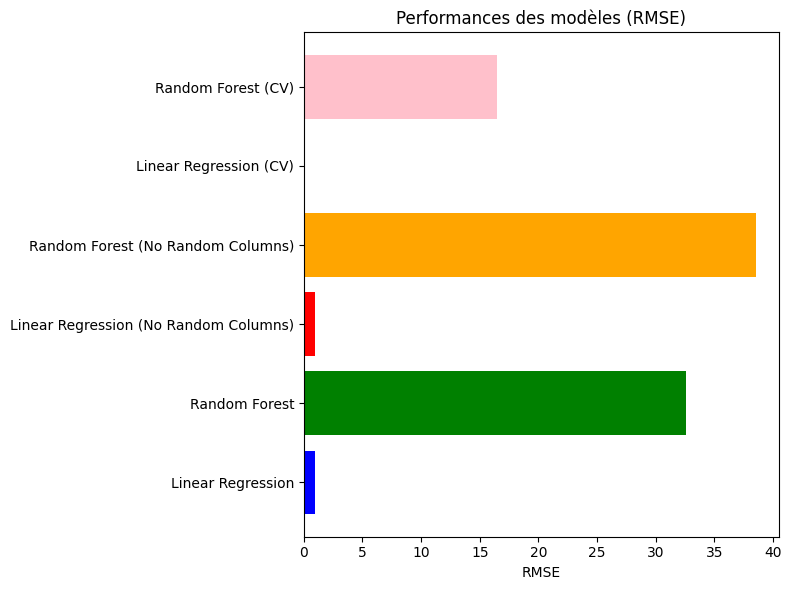

In [67]:


# Liste des modèles
models = ['Linear Regression', 'Random Forest', 'Linear Regression (No Random Columns)', 'Random Forest (No Random Columns)', 'Linear Regression (CV)', 'Random Forest (CV)']

# Liste des RMSE correspondants
rmse_values = [rmse_lr, rmse_rf, rmse_lr_no_random, rmse_rf_no_random, rmse_lr_cv, rmse_rf_cv]

# Liste des temps d'entraînement correspondants
training_times = [training_time_lr, training_time_rf, training_time_lr_no_random, training_time_rf_no_random, training_time_lr_cv, training_time_rf_cv]

# Création de la première figure pour les performances RMSE
plt.figure(figsize=(8, 6))
plt.barh(models, rmse_values, color=['blue', 'green', 'red', 'orange', 'purple', 'pink'])
plt.xlabel('RMSE')
plt.title('Performances des modèles (RMSE)')
plt.tight_layout()

plt.savefig('performances.png')
plt.show()




## Comparaison graphique du temps d'entraînement

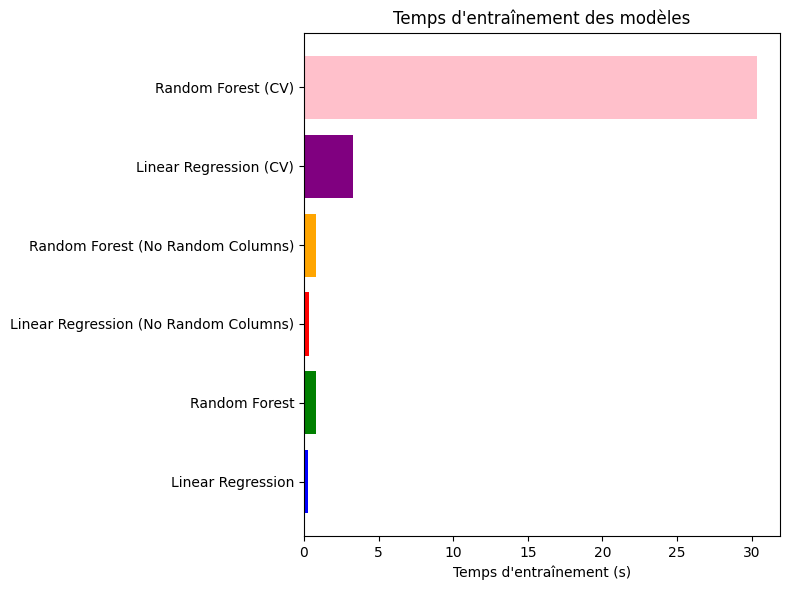

In [66]:
# Création de la deuxième figure pour les temps d'entraînement
plt.figure(figsize=(8, 6))
plt.barh(models, training_times, color=['blue', 'green', 'red', 'orange', 'purple', 'pink'])
plt.xlabel('Temps d\'entraînement (s)')
plt.title('Temps d\'entraînement des modèles')
plt.tight_layout()

plt.savefig('entrainement.png')
plt.show()

## Que retient-on de cette étude ?

Les résultats indiquent que les modèles avec validation croisée obtiennent généralement de meilleures performances en termes de RMSE par rapport à leurs homologues sans validation croisée. Cependant, les modèles sans validation croisée ont des temps d'entraînement plus courts. En d'autres termes, la validation croisée semble améliorer la généralisation des modèles, mais au prix d'un temps d'entraînement plus long.